# 250 km and 500 km case extensions
The large scale images are centered at the 100 km case locations where possible, and shifted to be within the boundaries.

In [48]:
import pandas as pd
import numpy as np
import pyproj

region_boundaries = pd.read_csv('../data/metadata/region_definitions.csv', index_col=0)
case_list = pd.read_csv('../data/validation_dataset/validation_dataset.csv', index_col=0)

In [63]:
crs0 = pyproj.CRS('WGS84')
crs1 = pyproj.CRS('epsg:3413')
transformer_xy_ll = pyproj.Transformer.from_crs(crs1, crs_to=crs0, always_xy=True)

case_list_250_km = case_list.copy()
dx = 125e3
for row, data in case_list_250_km.iterrows():
    data['left_x'] = data['center_x'] - dx
    data['right_x'] = data['center_x'] + dx
    data['lower_y'] = data['center_y'] - dx
    data['upper_y'] = data['center_y'] + dx
    region_left = region_boundaries.loc[data['region'], 'left_x']
    region_right = region_boundaries.loc[data['region'], 'right_x']
    region_upper = region_boundaries.loc[data['region'], 'upper_y']
    region_lower = region_boundaries.loc[data['region'], 'lower_y']

    if region_left > data['left_x']:
        adj_dx = region_left - data['left_x']
        data['left_x'] += adj_dx
        data['right_x'] += adj_dx
        data['center_x'] += adj_dx
        
    elif region_right < data['right_x']:
        adj_dx = data['right_x'] - region_right
        data['left_x'] -= adj_dx
        data['right_x'] -= adj_dx
        data['center_x'] -= adj_dx

    if region_lower > data['lower_y']:
        adj_dy = region_lower - data['lower_y']
        data['lower_y'] += adj_dy
        data['upper_y'] += adj_dy
        data['center_y'] += adj_dy
        
    elif region_upper < data['upper_y']:
        adj_dy = data['upper_y'] - region_upper
        data['lower_y'] -= adj_dy
        data['upper_y'] -= adj_dy
        data['center_y'] -= adj_dy
    
    case_list_250_km.loc[row, 'left_x'] = data['left_x']
    case_list_250_km.loc[row, 'right_x'] = data['right_x']
    case_list_250_km.loc[row, 'lower_y'] = data['lower_y']
    case_list_250_km.loc[row, 'upper_y'] = data['upper_y']
    case_list_250_km.loc[row, 'center_x'] = data['center_x']
    case_list_250_km.loc[row, 'center_y'] = data['center_y']

lon, lat = transformer_xy_ll.transform(case_list_250_km.center_x, case_list_250_km.center_y)
case_list_250_km['center_lon'] = lon.round(3)
case_list_250_km['center_lat'] = lat.round(3)


In [62]:
crs0 = pyproj.CRS('WGS84')
crs1 = pyproj.CRS('epsg:3413')
transformer_xy_ll = pyproj.Transformer.from_crs(crs1, crs_to=crs0, always_xy=True)

case_list_500_km = case_list.copy()
dx = 250e3
for row, data in case_list_500_km.iterrows():
    data['left_x'] = data['center_x'] - dx
    data['right_x'] = data['center_x'] + dx
    data['lower_y'] = data['center_y'] - dx
    data['upper_y'] = data['center_y'] + dx
    region_left = region_boundaries.loc[data['region'], 'left_x']
    region_right = region_boundaries.loc[data['region'], 'right_x']
    region_upper = region_boundaries.loc[data['region'], 'upper_y']
    region_lower = region_boundaries.loc[data['region'], 'lower_y']

    if region_left > data['left_x']:
        adj_dx = region_left - data['left_x']
        data['left_x'] += adj_dx
        data['right_x'] += adj_dx
        data['center_x'] += adj_dx
        
    elif region_right < data['right_x']:
        adj_dx = data['right_x'] - region_right
        data['left_x'] -= adj_dx
        data['right_x'] -= adj_dx
        data['center_x'] -= adj_dx

    if region_lower > data['lower_y']:
        adj_dy = region_lower - data['lower_y']
        data['lower_y'] += adj_dy
        data['upper_y'] += adj_dy
        data['center_y'] += adj_dy
        
    elif region_upper < data['upper_y']:
        adj_dy = data['upper_y'] - region_upper
        data['lower_y'] -= adj_dy
        data['upper_y'] -= adj_dy
        data['center_y'] -= adj_dy
    
    case_list_500_km.loc[row, 'left_x'] = data['left_x']
    case_list_500_km.loc[row, 'right_x'] = data['right_x']
    case_list_500_km.loc[row, 'lower_y'] = data['lower_y']
    case_list_500_km.loc[row, 'upper_y'] = data['upper_y']
    case_list_500_km.loc[row, 'center_x'] = data['center_x']
    case_list_500_km.loc[row, 'center_y'] = data['center_y']

lon, lat = transformer_xy_ll.transform(case_list_500_km.center_x, case_list_500_km.center_y)
case_list_500_km['center_lon'] = lon.round(3)
case_list_500_km['center_lat'] = lat.round(3)

<a list of 1 Line2D objects>

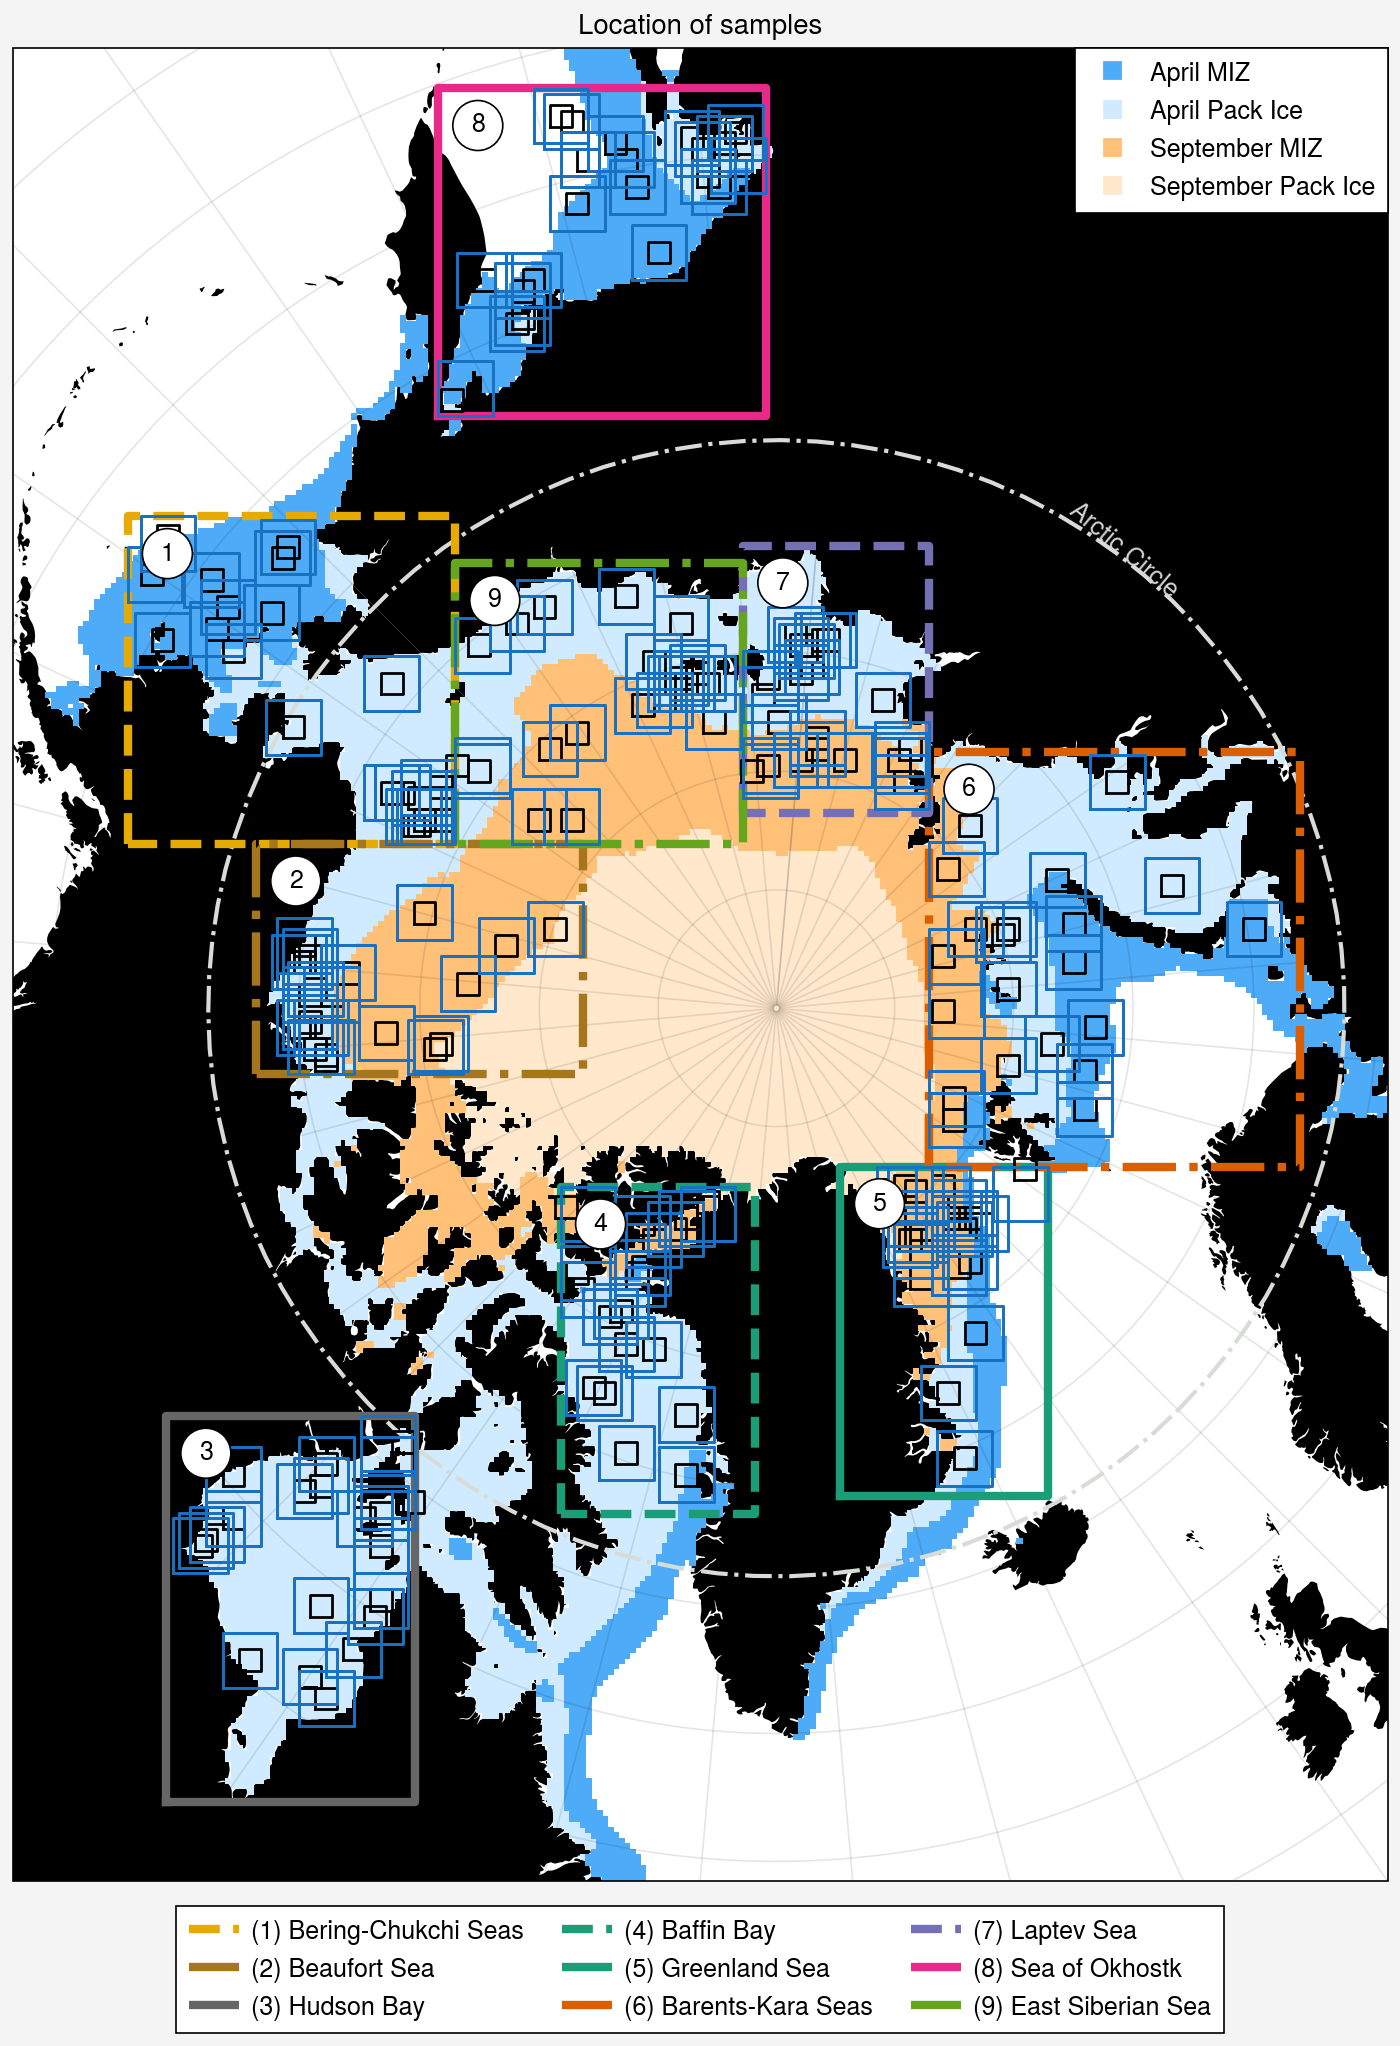

In [51]:
import pandas as pd
import ultraplot as uplt
import cartopy.crs as ccrs
import numpy as np
import warnings
import xarray as xr
import pyproj
import os

warnings.simplefilter('ignore')

uplt.rc['reso'] = 'med'
uplt.rc['cartopy.circular'] = False

# Load SIC mean data
ds_april_mean = xr.open_dataset('../data/nsidc/mean_sic_april_2000-2024.nc')
ds_sept_mean = xr.open_dataset('../data/nsidc/mean_sic_september_2000-2024.nc')
X = ds_april_mean.x
Y = ds_sept_mean.y

# Load region data
regions = pd.read_csv('../data/metadata/region_definitions.csv', index_col=0)
regions['print_title'] = [c.replace('_', ' ').title().replace('Of', 'of') for c in regions.index]

# Put in longitude order starting with Greenland
regions = regions.loc[['greenland_sea',
                       'barents_kara_seas',
                       'laptev_sea',
                       'sea_of_okhostk',
                       'east_siberian_sea',
                       'bering_chukchi_seas',
                       'beaufort_sea',
                       'hudson_bay',
                       'baffin_bay'],:]


df = pd.read_csv('../data/validation_dataset/validation_dataset.csv', parse_dates=['start_date'])
df['month'] = df['start_date'].dt.month
df = df.loc[df.satellite=='aqua']
df.index = [str(x).zfill(3) for x in df.case_number]

crs = ccrs.NorthPolarStereo(central_longitude=-45, true_scale_latitude=70)
fig, ax = uplt.subplots(width=7, proj='npstere', proj_kw={'lon_0': -45})
ax.format(land=True, color='k', boundinglat=52, landzorder=0, latmax=90, facecolor='w', lonlocator=10)
ax.set_extent([-3.5e6, 2.8e6, -4e6, 4.4e6], crs=crs)
    
    
colors = {region: c['color'] for region, c in zip(
            regions.index,
            uplt.Cycle('dark2', len(regions)))}
linestyles = {region: ls for region, ls in zip(regions.index,
                        ['-', '-.', '--', '-', '-.', '--', '-.', '-', '--'])}

regions['print_title'] = [c.replace('_', ' ').title().replace('Of', 'of') for c in regions.index]
regions = regions.sort_values('center_lon')

for idx, row in regions.iterrows():
    if row.print_title == 'Barents Kara Seas':
        regions.loc[idx, 'print_title'] = 'Barents-Kara Seas'
    if row.print_title == 'Bering Chukchi Seas':
        regions.loc[idx, 'print_title'] = 'Bering-Chukchi Seas'


miz = (ds_april_mean['cdr_seaice_conc_monthly'] > 0.15) & \
            (ds_april_mean['cdr_seaice_conc_monthly'] < 0.85)
april_miz = np.ma.masked_array(np.ones(miz.data.shape), mask=~miz)    

miz = (ds_sept_mean['cdr_seaice_conc_monthly'] > 0.15) &  \
            (ds_sept_mean['cdr_seaice_conc_monthly'] < 0.85)
sept_miz = np.ma.masked_array(np.ones(miz.data.shape), mask=~miz)    

apr_pack_ice = (ds_april_mean['cdr_seaice_conc_monthly'] >= 0.85) & \
            (ds_april_mean['cdr_seaice_conc_monthly'] <= 1)
apr_pack_ice = np.ma.masked_array(np.ones(apr_pack_ice.data.shape), mask=~apr_pack_ice)    

sep_pack_ice = (ds_sept_mean['cdr_seaice_conc_monthly'] >= 0.85) & \
            (ds_sept_mean['cdr_seaice_conc_monthly'] <= 1)

sep_pack_ice = np.ma.masked_array(np.ones(sep_pack_ice.data.shape), mask=~sep_pack_ice)    


ax.pcolormesh(X, Y, apr_pack_ice, vmin=0, vmax=1, color='blue1', alpha=1,
              transform=crs, label='')
ax.pcolormesh(X, Y, april_miz, vmin=0, vmax=1, color='blue4', alpha=1,
              transform=crs, label='')
ax.pcolormesh(X, Y, sep_pack_ice, vmin=0, vmax=1, color='orange1', alpha=1,
              transform=crs, label='')
ax.pcolormesh(X, Y, sept_miz, vmin=0, vmax=1, color='orange3', alpha=1,
              transform=crs, label='September MIZ')

h = [ax.plot([],[],marker='s', lw=0, color=color) for color in ['blue4', 'blue1', 'orange3', 'orange1']]
ax.legend(h, ['April MIZ', 'April Pack Ice', 'September MIZ', 'September Pack Ice'], loc='ur', ncols=1, alpha=1)


idx = 1
for idx, region, lat, lon in zip(range(len(regions)), regions.index, regions.center_lat, regions.center_lon):

    xbox = np.array(regions.loc[region, ['left_x', 'left_x', 'right_x', 'right_x', 'left_x']].astype(float))
    ybox = np.array(regions.loc[region, ['lower_y', 'upper_y', 'upper_y', 'lower_y', 'lower_y']].astype(float))
    
    ax.plot(xbox, ybox, transform=crs,
            label='({n}) {t}'.format(n=idx + 1, t=regions.loc[region, 'print_title']), 
               color=colors[region], ls=linestyles[region], m='', zorder=5, lw=3)

ice_floes_cases = df.loc[df.visible_floes == 'yes']
no_floes_cases = df.loc[df.visible_floes == 'no']


ax.set_extent([-3.5e6, 2.8e6, -4e6, 4.4e6], crs=crs)

for idx, case in df.iterrows():
    x0 = case.center_x
    y0 = case.center_y
    left = x0 - 50e3
    right = x0 + 50e3
    bottom = y0 - 50e3
    top = y0 + 50e3 
    region = case.region
    c = 'k'
    z = 20
    ax.plot([left, left, right, right, left],
        [bottom, top, top, bottom, bottom], label='',
            transform=crs, color=c, lw=1, zorder=z)

for idx, case in case_list_250_km.iterrows():
    x0 = case.center_x
    y0 = case.center_y
    left = case.left_x
    right = case.right_x
    bottom = case.lower_y
    top = case.upper_y
    region = case.region
    c = 'blue8'
    z = 25
    ax.plot([left, left, right, right, left],
        [bottom, top, top, bottom, bottom], label='',
            transform=crs, color=c, lw=1, zorder=z)
   
# ax.plot([],[],m='s', color='gray', label='No visible floes', lw=0)


idx = 1
for region in regions.index:
    ax.text(regions.loc[region, 'left_x'] + 150e3,
            regions.loc[region, 'upper_y'] - 200e3, str(idx),
            transform=crs, bbox=True, bboxalpha=1,
            border=False, color='k', borderwidth=0,
            bboxstyle='circle', bboxcolor='w', zorder=30)
    idx += 1
ax.text(100, 69, 'Arctic Circle', color='lightgray', transform=ccrs.PlateCarree(), rotation=-40)

ax.format(title='Location of samples')
fig.legend(ncols=3, alpha=1, loc='b', order='F')

ax.plot(np.linspace(0, 360, 100), np.ones(100)*66.3, ls='-.', color='light gray')
# fig.save('../figures/fig_01_sample_locations_map.png', dpi=300)

<a list of 1 Line2D objects>

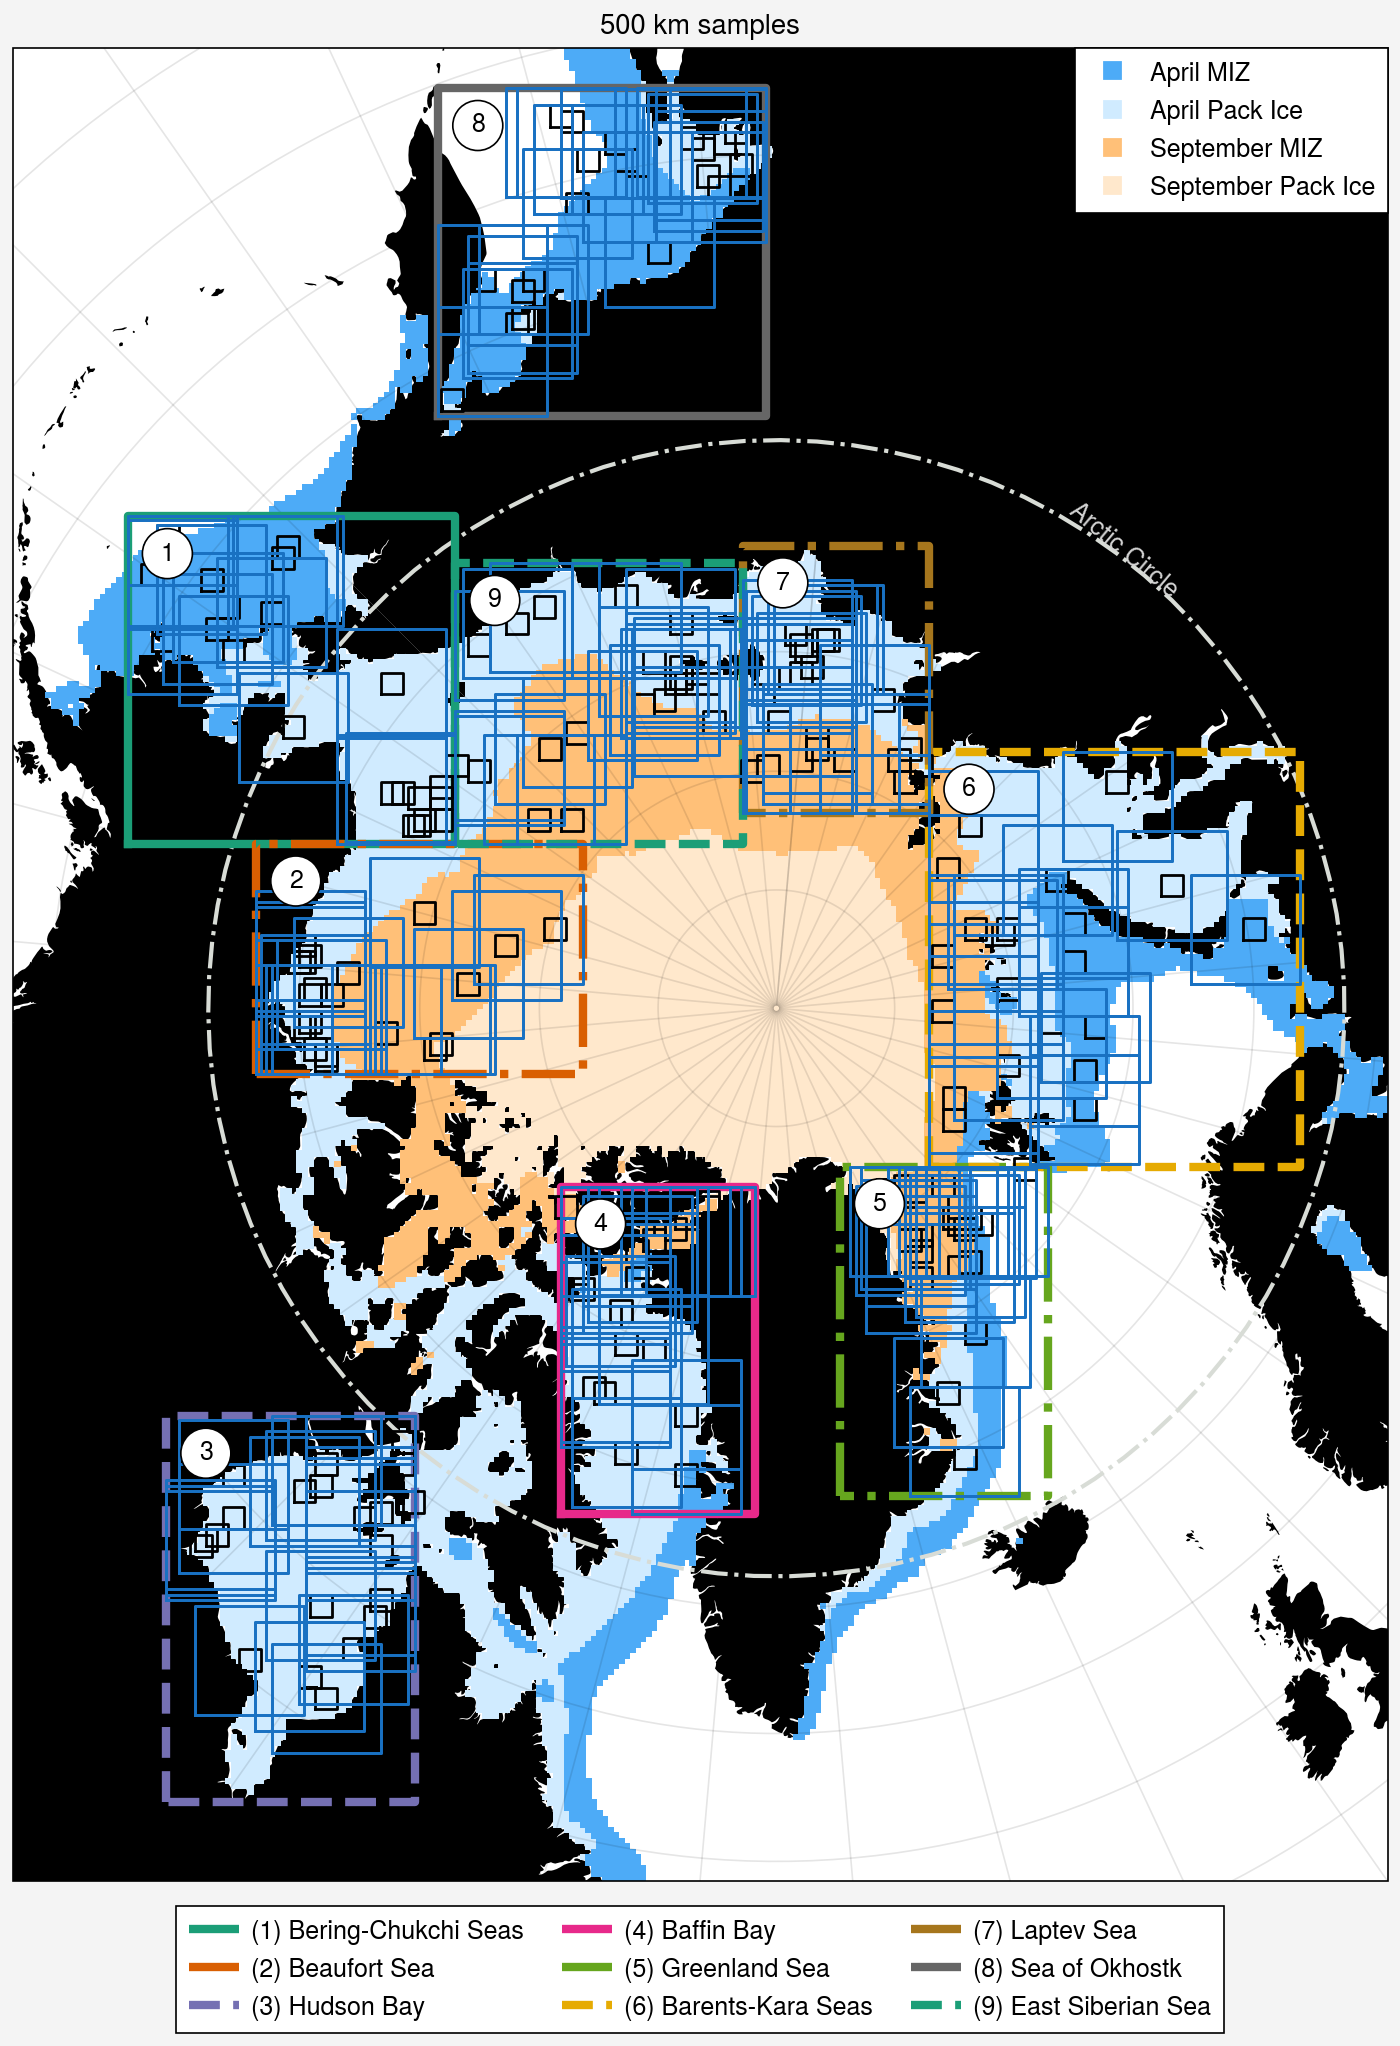

In [85]:
# Same as above with 500 km cases

crs = ccrs.NorthPolarStereo(central_longitude=-45, true_scale_latitude=70)
fig, ax = uplt.subplots(width=7, proj='npstere', proj_kw={'lon_0': -45})
ax.format(land=True, color='k', boundinglat=52, landzorder=0, latmax=90, facecolor='w', lonlocator=10)
ax.set_extent([-3.5e6, 2.8e6, -4e6, 4.4e6], crs=crs)
    
    
colors = {region: c['color'] for region, c in zip(
            regions.index,
            uplt.Cycle('dark2', len(regions)))}
linestyles = {region: ls for region, ls in zip(regions.index,
                        ['-', '-.', '--', '-', '-.', '--', '-.', '-', '--'])}

regions['print_title'] = [c.replace('_', ' ').title().replace('Of', 'of') for c in regions.index]
regions = regions.sort_values('center_lon')

for idx, row in regions.iterrows():
    if row.print_title == 'Barents Kara Seas':
        regions.loc[idx, 'print_title'] = 'Barents-Kara Seas'
    if row.print_title == 'Bering Chukchi Seas':
        regions.loc[idx, 'print_title'] = 'Bering-Chukchi Seas'


miz = (ds_april_mean['cdr_seaice_conc_monthly'] > 0.15) & \
            (ds_april_mean['cdr_seaice_conc_monthly'] < 0.85)
april_miz = np.ma.masked_array(np.ones(miz.data.shape), mask=~miz)    

miz = (ds_sept_mean['cdr_seaice_conc_monthly'] > 0.15) &  \
            (ds_sept_mean['cdr_seaice_conc_monthly'] < 0.85)
sept_miz = np.ma.masked_array(np.ones(miz.data.shape), mask=~miz)    

apr_pack_ice = (ds_april_mean['cdr_seaice_conc_monthly'] >= 0.85) & \
            (ds_april_mean['cdr_seaice_conc_monthly'] <= 1)
apr_pack_ice = np.ma.masked_array(np.ones(apr_pack_ice.data.shape), mask=~apr_pack_ice)    

sep_pack_ice = (ds_sept_mean['cdr_seaice_conc_monthly'] >= 0.85) & \
            (ds_sept_mean['cdr_seaice_conc_monthly'] <= 1)

sep_pack_ice = np.ma.masked_array(np.ones(sep_pack_ice.data.shape), mask=~sep_pack_ice)    


ax.pcolormesh(X, Y, apr_pack_ice, vmin=0, vmax=1, color='blue1', alpha=1,
              transform=crs, label='')
ax.pcolormesh(X, Y, april_miz, vmin=0, vmax=1, color='blue4', alpha=1,
              transform=crs, label='')
ax.pcolormesh(X, Y, sep_pack_ice, vmin=0, vmax=1, color='orange1', alpha=1,
              transform=crs, label='')
ax.pcolormesh(X, Y, sept_miz, vmin=0, vmax=1, color='orange3', alpha=1,
              transform=crs, label='September MIZ')

h = [ax.plot([],[],marker='s', lw=0, color=color) for color in ['blue4', 'blue1', 'orange3', 'orange1']]
ax.legend(h, ['April MIZ', 'April Pack Ice', 'September MIZ', 'September Pack Ice'], loc='ur', ncols=1, alpha=1)


idx = 1
for idx, region, lat, lon in zip(range(len(regions)), regions.index, regions.center_lat, regions.center_lon):

    xbox = np.array(regions.loc[region, ['left_x', 'left_x', 'right_x', 'right_x', 'left_x']].astype(float))
    ybox = np.array(regions.loc[region, ['lower_y', 'upper_y', 'upper_y', 'lower_y', 'lower_y']].astype(float))
    
    ax.plot(xbox, ybox, transform=crs,
            label='({n}) {t}'.format(n=idx + 1, t=regions.loc[region, 'print_title']), 
               color=colors[region], ls=linestyles[region], m='', zorder=5, lw=3)

ice_floes_cases = df.loc[df.visible_floes == 'yes']
no_floes_cases = df.loc[df.visible_floes == 'no']


ax.set_extent([-3.5e6, 2.8e6, -4e6, 4.4e6], crs=crs)

for idx, case in df.iterrows():
    x0 = case.center_x
    y0 = case.center_y
    left = x0 - 50e3
    right = x0 + 50e3
    bottom = y0 - 50e3
    top = y0 + 50e3 
    region = case.region
    c = 'k'
    z = 20
    ax.plot([left, left, right, right, left],
        [bottom, top, top, bottom, bottom], label='',
            transform=crs, color=c, lw=1, zorder=z)

for idx, case in case_list_500_km.iterrows():
    x0 = case.center_x
    y0 = case.center_y
    left = case.left_x
    right = case.right_x
    bottom = case.lower_y
    top = case.upper_y
    region = case.region
    c = 'blue8'
    z = 25
    ax.plot([left, left, right, right, left],
        [bottom, top, top, bottom, bottom], label='',
            transform=crs, color=c, lw=1, zorder=z)

idx = 1
for region in regions.index:
    ax.text(regions.loc[region, 'left_x'] + 150e3,
            regions.loc[region, 'upper_y'] - 200e3, str(idx),
            transform=crs, bbox=True, bboxalpha=1,
            border=False, color='k', borderwidth=0,
            bboxstyle='circle', bboxcolor='w', zorder=30)
    idx += 1
ax.text(100, 69, 'Arctic Circle', color='lightgray', transform=ccrs.PlateCarree(), rotation=-40)

ax.format(title='500 km samples')
fig.legend(ncols=3, alpha=1, loc='b', order='F')

ax.plot(np.linspace(0, 360, 100), np.ones(100)*66.3, ls='-.', color='light gray')
# fig.save('../figures/fig_01_sample_locations_map.png', dpi=300)

In [78]:
# Export for Snakemake
columns = [
    'case_number',
    'region_name',
    'center_lon',
    'center_lat',
    'center_x',
    'center_y',
    'start',
    'end',
    'scale',
    'center_crs',
    'region',
    'target_crs',
    'pipeline',
    'target_width',
    'target_height'
]
case_list_100_km = case_list.copy()

case_list_100_km.rename({'start_date': 'start', 'end_date': 'end', 'region': 'region_name'}, axis=1, inplace=True)
case_list_100_km['end'] = case_list_100_km['start']
case_list_100_km['pipeline'] = 'FSPipeline'
case_list_100_km['scale'] = 250
case_list_100_km['target_width'] = 250000
case_list_100_km['target_height'] = 250000
case_list_100_km['center_crs'] = 'EPSG:4326'
case_list_100_km['target_crs'] = 'EPSG:3413'
case_list_100_km['region'] = ['{r}_{n}'.format(r=r, n=str(n).zfill(3)) for r, n in zip(
    case_list_100_km.region_name, case_list_100_km.case_number)]

case_list_250_km.rename({'start_date': 'start', 'region': 'region_name'}, axis=1, inplace=True)
case_list_250_km['end'] = case_list_250_km['start']
case_list_250_km['pipeline'] = 'FSPipeline'
case_list_250_km['scale'] = 250
case_list_250_km['target_width'] = 250000
case_list_250_km['target_height'] = 250000
case_list_250_km['center_crs'] = 'EPSG:4326'
case_list_250_km['target_crs'] = 'EPSG:3413'
case_list_250_km['region'] = ['{r}_{n}'.format(r=r, n=str(n).zfill(3)) for r, n in zip(
    case_list_250_km.region_name, case_list_250_km.case_number)]

case_list_500_km.rename({'start_date': 'start', 'end_date': 'end', 'region': 'region_name'}, axis=1, inplace=True)
case_list_500_km['end'] = case_list_500_km['start']
case_list_500_km['pipeline'] = 'FSPipeline'
case_list_500_km['scale'] = 250
case_list_500_km['target_width'] = 250000
case_list_500_km['target_height'] = 250000
case_list_500_km['center_crs'] = 'EPSG:4326'
case_list_500_km['target_crs'] = 'EPSG:3413'
case_list_500_km['region'] = ['{r}_{n}'.format(r=r, n=str(n).zfill(3)) for r, n in zip(
    case_list_500_km.region_name, case_list_500_km.case_number)]

In [84]:
idx = case_list.satellite == 'aqua'
case_list_100_km.loc[idx, columns].to_csv('../data/metadata/validation-region-case-100km.csv', index=False)
case_list_250_km.loc[idx, columns].to_csv('../data/metadata/validation-region-case-250km.csv', index=False)
case_list_500_km.loc[idx, columns].to_csv('../data/metadata/validation-region-case-500km.csv', index=False)

In [76]:
case_list_500_km.loc[:, columns].to_csv('../data/metadata/validation-region-case-500km.csv')
case_list_250_km.loc[:, columns].to_csv('../data/metadata/validation-region-case-250km.csv')

,case_number,region_name,center_lon,center_lat,center_x,center_y,start,end,scale,center_crs,region,target_crs,pipeline,target_width,target_height
0,1,baffin_bay,-79.611,78.060,-737231,-1068234,2022-09-11,2022-09-11,250,EPSG:4326,baffin_bay_001,EPSG:3413,FSPipeline,250000,250000
1,1,baffin_bay,-79.611,78.060,-737231,-1068234,2022-09-11,2022-09-11,250,EPSG:4326,baffin_bay_001,EPSG:3413,FSPipeline,250000,250000
2,2,baffin_bay,-76.301,76.955,-737231,-1212500,2015-03-12,2015-03-12,250,EPSG:4326,baffin_bay_002,EPSG:3413,FSPipeline,250000,250000
3,2,baffin_bay,-76.301,76.955,-737231,-1212500,2015-03-12,2015-03-12,250,EPSG:4326,baffin_bay_002,EPSG:3413,FSPipeline,250000,250000
4,3,baffin_bay,-74.796,76.366,-737231,-1287500,2012-04-19,2012-04-19,250,EPSG:4326,baffin_bay_003,EPSG:3413,FSPipeline,250000,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,187,sea_of_okhostk,155.731,59.728,-1187500,3137500,2013-04-29,2013-04-29,250,EPSG:4326,sea_of_okhostk_187,EPSG:3413,FSPipeline,250000,250000
374,188,sea_of_okhostk,156.280,57.779,-1299890,3337500,2015-03-12,2015-03-12,250,EPSG:4326,sea_of_okhostk_188,EPSG:3413,FSPipeline,250000,250000
375,188,sea_of_okhostk,156.280,57.779,-1299890,3337500,2015-03-12,2015-03-12,250,EPSG:4326,sea_of_okhostk_188,EPSG:3413,FSPipeline,250000,250000
376,189,sea_of_okhostk,158.675,60.744,-1299890,2964708,2012-04-26,2012-04-26,250,EPSG:4326,sea_of_okhostk_189,EPSG:3413,FSPipeline,250000,250000
